# Assignment 11: Breast Cancer Prediction using Decision Tree

**Name:** Ashar Khan
**Batch:** Data Science Weekday – Hyderabad  
**Topic:** Decision Tree Classification

## Loading the Dataset

In this assignment, instead of using an external dataset file, we are using a built-in dataset available in the scikit-learn library. This dataset is widely used for classification problems and is clean, well-structured, and ready for analysis.

The dataset contains multiple features that describe medical characteristics of patients. The target variable indicates whether the condition is present or not.

Using a built-in dataset ensures that there are no issues related to missing values, incorrect formatting, or data inconsistencies. This allows us to focus more on understanding the machine learning workflow, including model building, evaluation, and interpretation.

This step helps us quickly set up a reliable dataset for further analysis and model development.

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Data Understanding

In this step, we explore the dataset to understand its structure and characteristics. The dataset contains multiple numerical features that represent different medical measurements.

We use functions like info() to check the data types and confirm that all features are numerical. The describe() function provides statistical summaries such as mean, standard deviation, minimum, and maximum values.

The target variable represents the classification outcome, where:
- 0 indicates one class
- 1 indicates another class

Understanding the dataset is important because it helps us identify whether any preprocessing is required. In this case, since the dataset is already clean and numerical, minimal preprocessing is needed.

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution and patterns in the dataset. Since all features are numerical, we can directly visualize them using histograms and boxplots.

Histograms allow us to observe how values are distributed across different features. This helps identify whether the data follows a normal distribution or is skewed. Boxplots help detect outliers and understand the spread of the data.

EDA provides important insights into the dataset, which helps us make better decisions during model building. It also ensures that the data is suitable for machine learning algorithms.

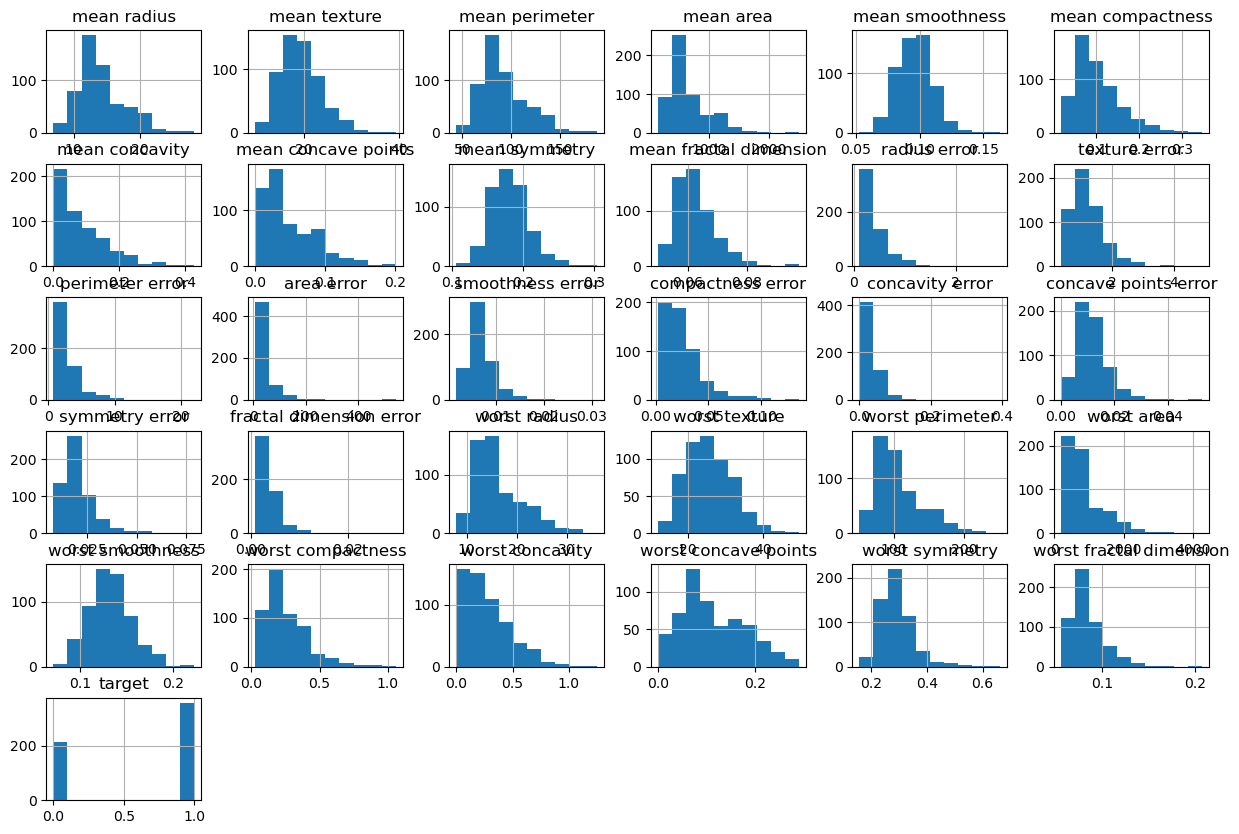

In [ ]:
import matplotlib.pyplot as plt
df.hist(figsize=(15,10))
plt.show()

## Box Plot Analysis

Box plots help us identify outliers in the dataset. Outliers are extreme values that can affect model performance.

By visualizing box plots, we can understand the spread of the data and detect any unusual values. This helps improve model accuracy and reliability.

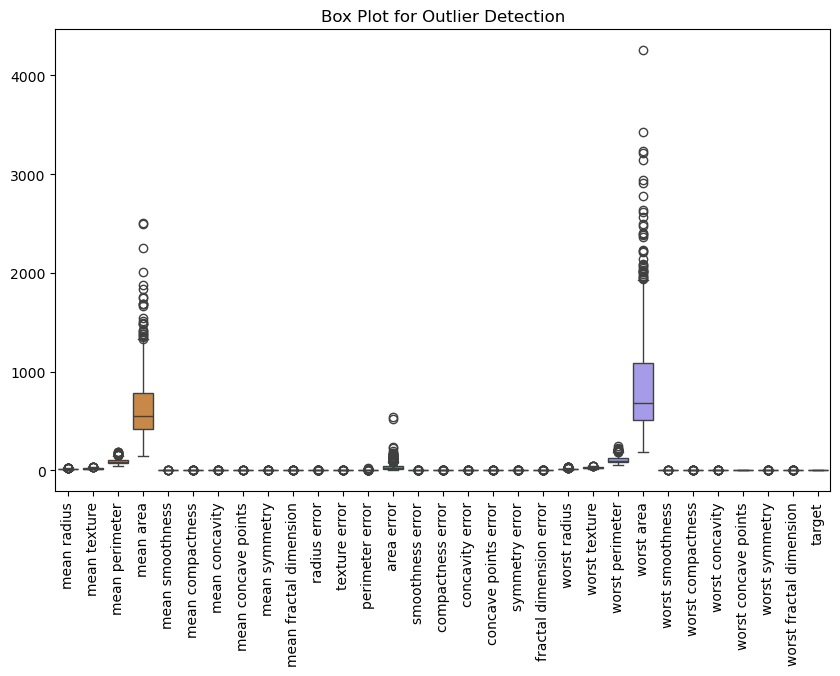

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Box Plot for Outlier Detection")
plt.show()

## Correlation Analysis

Correlation analysis helps us understand the relationships between different features in the dataset. We use a heatmap to visualize correlation values.

A high correlation indicates a strong relationship between features, while low correlation indicates independence. This helps us identify important features and avoid redundancy.

Understanding correlations can improve model performance by selecting relevant features and reducing unnecessary complexity.

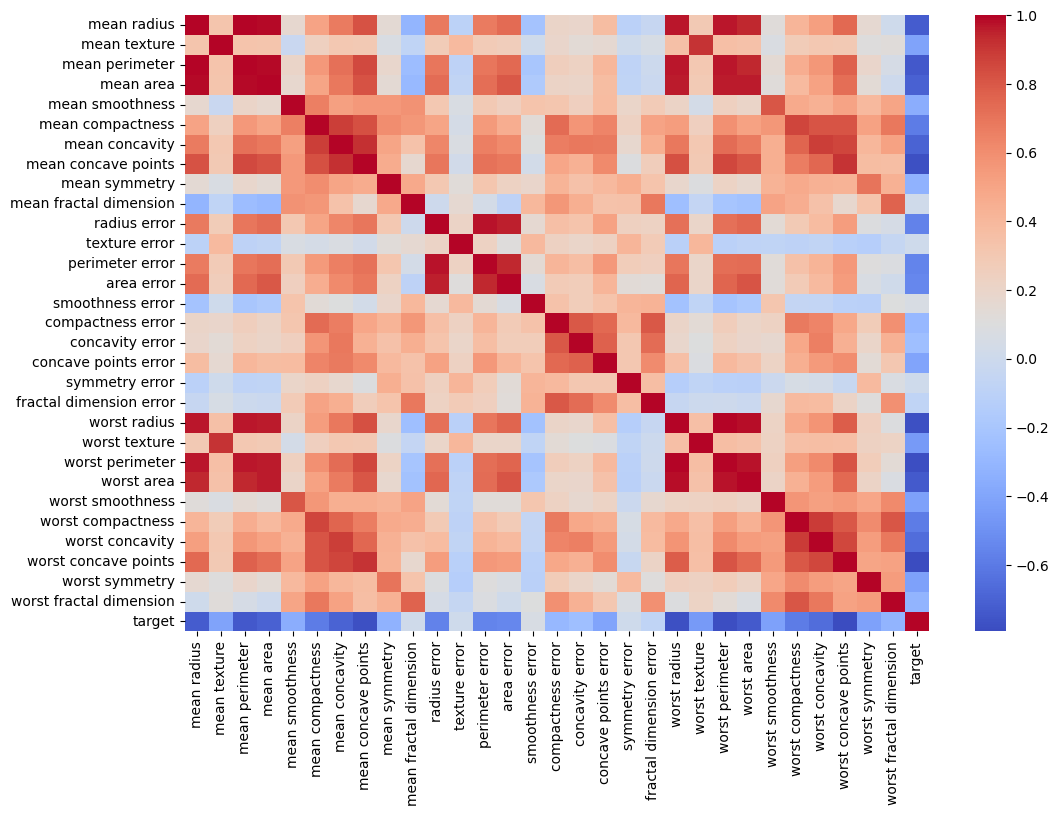

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

## Data Preprocessing

In this dataset, all features are already numerical and there are no missing values. Therefore, minimal preprocessing is required.

We simply separate the dataset into input features (X) and the target variable (y). The features will be used by the model to learn patterns, while the target variable represents the output we want to predict.

This step is important because it prepares the data in a format suitable for machine learning models.

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

## Train-Test Split

We divide the dataset into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance.

This ensures that the model is tested on unseen data, which helps measure how well it generalizes to new data. An 80-20 split is commonly used to maintain a balance between training and testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Building Decision Tree Model

In this step, we build a Decision Tree Classification model. A decision tree works by splitting the data into smaller groups based on feature values.

Each split represents a decision rule, and the final output is determined at the leaf nodes. Decision Trees are easy to interpret and allow us to understand how the model makes predictions.

The model is trained using the training dataset and learns patterns that help classify new data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Model Evaluation

After training the model, we evaluate its performance using different metrics such as accuracy, precision, recall, and F1-score.

Accuracy measures the overall correctness of the model, while precision and recall provide deeper insights into classification performance. The F1-score balances both precision and recall.

We also use a confusion matrix to visualize the number of correct and incorrect predictions. This helps us understand where the model is performing well and where improvements are needed.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## Confusion Matrix

The confusion matrix is used to evaluate the performance of the classification model. It shows the number of correct and incorrect predictions made by the model.

It helps us understand how well the model is performing for each class and identifies where the model is making mistakes.

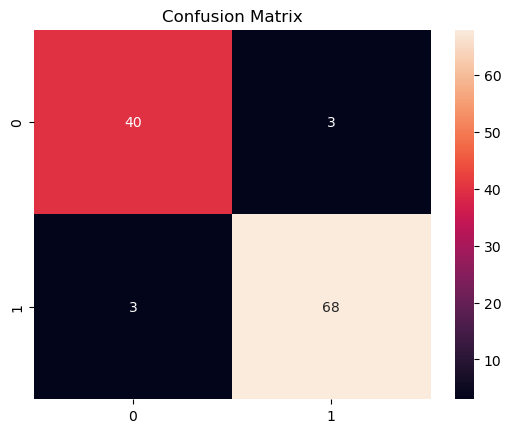

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## ROC Curve and AUC Score

ROC (Receiver Operating Characteristic) curve helps us evaluate the performance of a classification model. It shows the trade-off between True Positive Rate and False Positive Rate.

AUC (Area Under Curve) represents how well the model can distinguish between classes. A higher AUC score indicates better model performance.

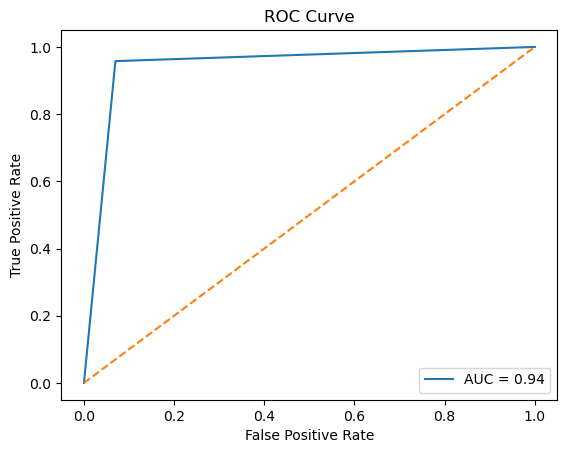

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert target to binary (for ROC)
y_test_bin = label_binarize(y_test, classes=[0,1])
y_pred_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test_bin, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC Curve Analysis

The ROC (Receiver Operating Characteristic) curve helps evaluate the performance of the classification model. It shows the relationship between the True Positive Rate (TPR) and False Positive Rate (FPR).

The AUC (Area Under Curve) score represents how well the model can distinguish between classes. In this model, the AUC score is approximately 0.94, which indicates excellent performance.

A value close to 1 means the model is highly capable of distinguishing between classes, while a value near 0.5 would indicate poor performance.

## Hyperparameter Tuning

Hyperparameter tuning helps improve model performance by selecting the best combination of parameters.

In Decision Trees, important parameters include maximum depth, minimum samples split, and criterion. We use GridSearchCV to test different combinations and find the best model configuration.

This helps reduce overfitting and improves the accuracy of the model.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

## Decision Tree Visualization

Visualizing the decision tree helps us understand how the model makes decisions. It shows how features are used to split the data and classify outcomes.

This is one of the key advantages of Decision Trees, as they provide transparency and interpretability.

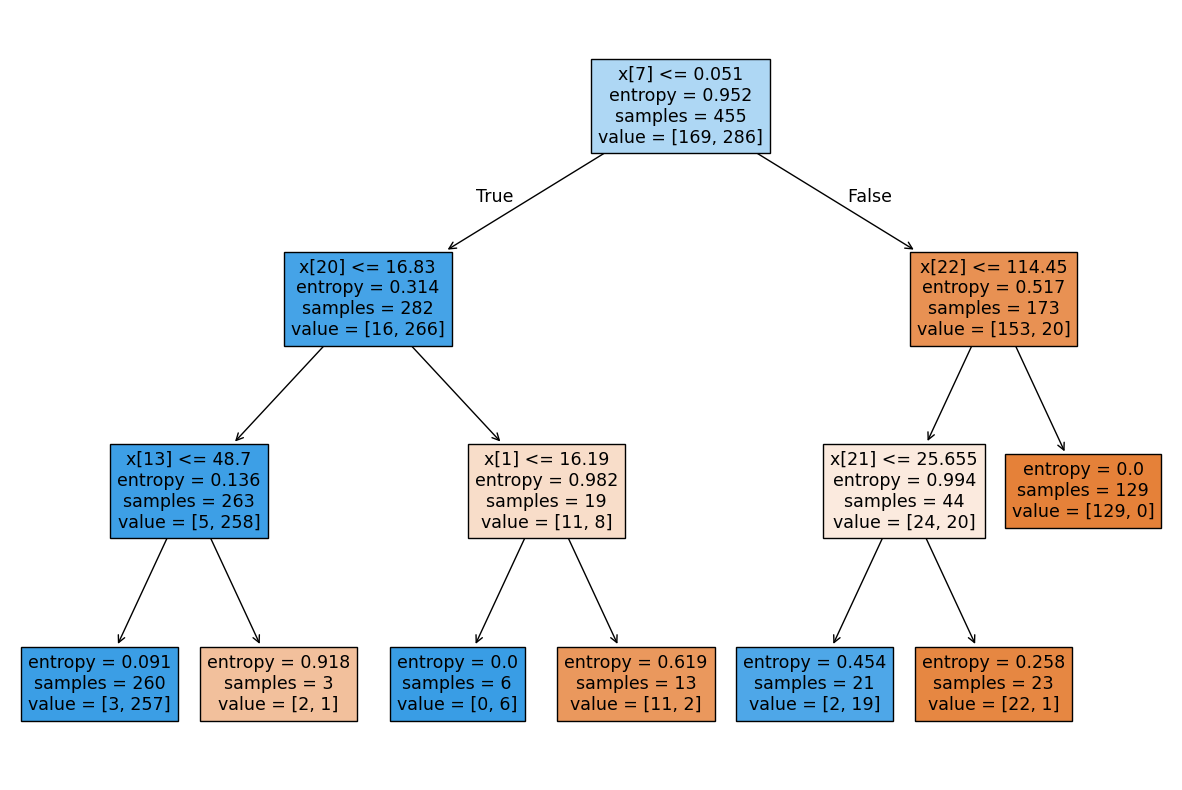

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True)
plt.show()

## Model Strengths and Limitations

### Strengths:
- Easy to understand and interpret  
- No need for feature scaling  
- Works well with both numerical and categorical data  

### Limitations:
- Can overfit if not properly tuned  
- Sensitive to small changes in data  
- Less stable compared to ensemble methods  

## Conclusion

In this assignment, we successfully implemented a Decision Tree Classification model using a standard dataset from the scikit-learn library. The dataset contained multiple numerical features representing medical measurements, along with a target variable used for classification.

We started by understanding the dataset and performing exploratory data analysis (EDA) to observe patterns and distributions. Since the dataset was already clean and structured, minimal preprocessing was required. We then split the data into training and testing sets and built a Decision Tree model.

The model was evaluated using performance metrics such as accuracy, precision, recall, and F1-score. We also visualized the confusion matrix to understand the model's prediction behavior. Additionally, hyperparameter tuning was performed to improve model performance by selecting optimal parameters.

One of the key advantages observed was the interpretability of the Decision Tree, as we were able to visualize the decision-making process. Overall, this assignment helped in understanding how Decision Trees work and how they can be applied to real-world classification problems, especially in healthcare scenarios.

## Interview Question Answers

### Q: What is the difference between Label Encoding and One-Hot Encoding?

Label Encoding converts categorical values into numerical labels. For example, “Red”, “Blue”, “Green” becomes 0, 1, 2. This method is simple but can introduce an unintended order among categories.

One-Hot Encoding, on the other hand, creates separate binary columns for each category. For example, “Red” becomes [1,0,0], “Blue” becomes [0,1,0]. This avoids any ordinal relationship and is preferred when categories do not have a natural order.

In summary, Label Encoding is useful for ordered data, while One-Hot Encoding is better for nominal data without hierarchy.

1. What is a Decision Tree?
2. What is overfitting in Decision Trees?
3. What is pruning?
4. Difference between Label Encoding and One-Hot Encoding?
5. What is ROC-AUC?